# Hopfield Network — Pattern Storage and Reconstruction

**Laboratory of Computational Physics — Project Report**

| | |
|---|---|
| **Model** | Classical Hopfield network (binary spins, $S_i \in \{+1,-1\}$) |
| **Datasets** | Random 2-D patterns · MNIST digit prototypes |
| **Learning rules** | Hebbian · Storkey · Local (radius R) |
| **Update methods** | Synchronous · Asynchronous · Monte Carlo (Metropolis) |

---

## Structure

1. [Theory recap](#1-theory)
2. [Setup & imports](#2-setup)
3. [Part A — Storing patterns: the J matrix](#3-part-a)
4. [Part B — Corrupting patterns](#4-part-b)
5. [Part C — Recovery: sign rule & Monte Carlo](#5-part-c)
6. [Part D — Storage capacity & overlap](#6-part-d)
7. [MNIST — digit prototypes](#7-mnist)
8. [Conclusions](#8-conclusions)


---
<a id="1-theory"></a>
## 1 — Theory recap

A Hopfield network is a fully connected recurrent network of $N$ binary neurons
$S_i \in \{+1,-1\}$ with symmetric, zero-diagonal coupling matrix $J_{ij}$.
Its Hamiltonian (energy function) is:

$$
H[\mathbf{S}] = -\frac{1}{2}\sum_{i \neq j} J_{ij} S_i S_j
$$

This is identical to the Ising spin-glass Hamiltonian with quenched disorder in
the couplings.  The couplings are chosen so that $P$ desired *patterns*
$\{\boldsymbol{\xi}^\mu\}_{\mu=1}^P$ are local energy minima (attractors).

### Hebbian learning

$$
J_{ij} = \frac{1}{N}\sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu, \qquad J_{ii}=0
$$

### Synchronous (sign) update rule

$$
S_i(t+1) = \operatorname{sgn}\!\left(\sum_j J_{ij} S_j(t)\right)
$$

Each application of this rule decreases (or preserves) the energy — the system
converges to a fixed point.

### Monte Carlo / Metropolis update

A random spin $i$ is selected; the energy change of flipping it is

$$
\Delta E_i = 2\,S_i\!\sum_j J_{ij}S_j
$$

The flip is accepted if $\Delta E_i \le 0$, otherwise with probability
$e^{-\Delta E_i/T}$.  Temperature $T$ allows the network to escape shallow
spurious minima.

### Storage capacity

The maximum number of storable patterns for reliable retrieval is approximately

$$
P_c \approx 0.138\,N
$$

Beyond this limit, interference between stored patterns degrades retrieval.


---
<a id="2-setup"></a>
## 2 — Setup & imports


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
import torch

# project modules
from funzioni_ausiliari_v2 import hopfield_model_torch
from patterns_v2           import generate_random_patterns, corrupt_patterns, corruption_map
from patterns_v2           import get_mnist_patterns
# Se i file hanno un suffisso diverso, aggiorna i nomi qui:
import sys, os


sys.path.insert(0, r'C:\Users\ginap\Documents\unipd\1_anno\LCP\LCP_A\progetto_LCP_A')

from funzioni_ausiliari_v2 import (plot_corruption_modes, plot_all_results,
                                plot_mnist_results, plot_energy_trace,
                                plot_overlap_vs_q, plot_overlap_vs_P,
                                plot_capacity_heatmap, grid_search)

# reproducibility
SEED = 42
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


---
<a id="3-part-a"></a>
## 3 — Part A: Storing patterns — the coupling matrix $J$

Given $P$ patterns we compute $J$ with the **Hebbian rule**:

$$
J_{ij} = \frac{1}{N}\sum_{\mu=1}^P \xi_i^\mu \xi_j^\mu
$$

We can visualise $J$ directly: positive entries (blue) link neurons that tend
to be *co-activated*; negative entries (red) link neurons with *opposite* states.


C:\Users\ginap\AppData\Local\Temp\ipykernel_41224\732777725.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


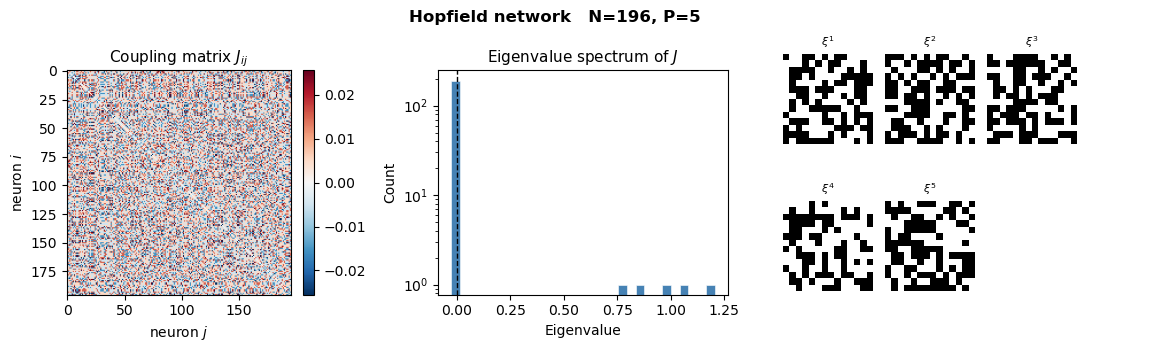

Theoretical capacity: P_c ≈ 27.0
Memory interference:  I  = 0.0633


In [2]:
shape      = (14, 14)
N          = shape[0] * shape[1]
n_patterns = 5

patterns = generate_random_patterns(shape, n_patterns, seed=SEED)
model    = hopfield_model_torch(patterns, update_method='synchronous',
                                learning_rule='hebb', verbose=False)

# ── visualise J ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# J matrix
im = axes[0].imshow(model.J.cpu().numpy(), cmap='RdBu_r', vmin=-model.J.abs().max().item(), vmax= model.J.abs().max().item())
axes[0].set_title('Coupling matrix $J_{ij}$', fontsize=11)
axes[0].set_xlabel('neuron $j$'); axes[0].set_ylabel('neuron $i$')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# eigenvalue spectrum
eigvals = torch.linalg.eigvalsh(model.J.cpu()).numpy()
axes[1].hist(eigvals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_yscale('log')
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_title('Eigenvalue spectrum of $J$', fontsize=11)
axes[1].set_xlabel('Eigenvalue'); axes[1].set_ylabel('Count')

# the stored patterns
axes[2].axis('off')
for mu, p in enumerate(patterns):
    ax_in = fig.add_axes([0.69 + (mu % 3) * 0.085,
                          0.55 - (mu // 3) * 0.42,
                          0.075, 0.35])
    ax_in.imshow((p + 1) / 2, cmap='gray', vmin=0, vmax=1)
    title_str = r'$\xi^{' + str(mu + 1) + r'}$'
    ax_in.set_title(title_str, fontsize=8)
    ax_in.axis('off')

plt.suptitle(f'Hopfield network   N={N}, P={n_patterns}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Theoretical capacity: P_c ≈ {model.storage_limit():.1f}")
print(f"Memory interference:  I  = {float(model.memory_interference()):.4f}")


**Reading the spectrum.** When $P \ll P_c$ the spectrum of $J$ is dominated
by $P$ large eigenvalues — each corresponding to a stored pattern — embedded in
a semicircular bulk of noise eigenvalues (Marchenko–Pastur law).  As $P$
approaches $P_c$ the signal eigenvalues are no longer separated from the noise
and retrieval fails.


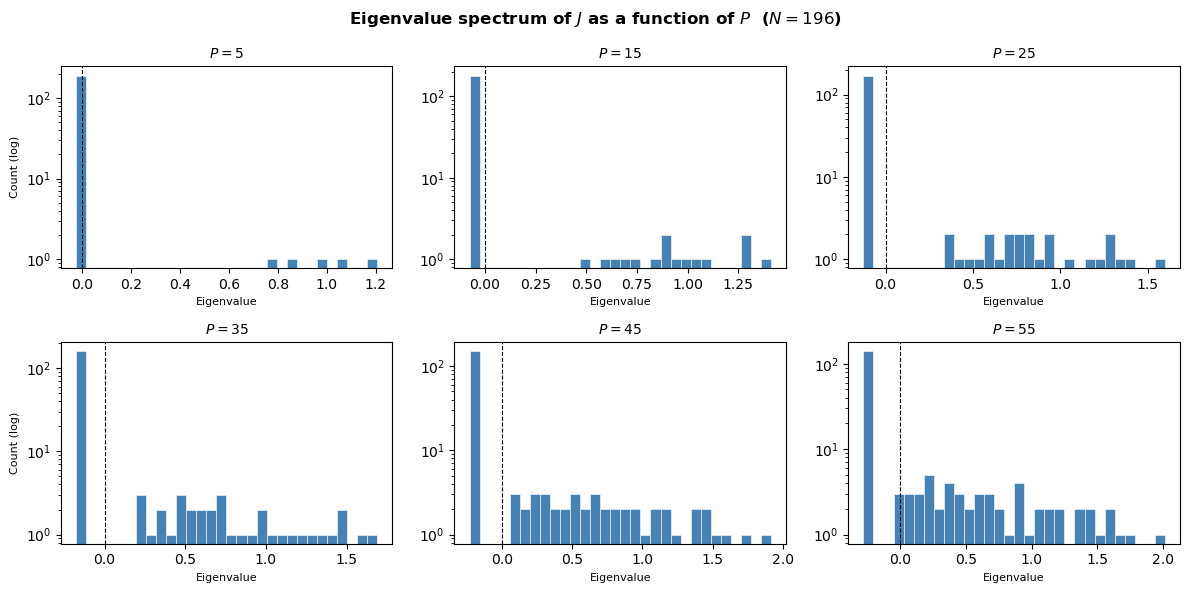

In [14]:
shape    = (14, 14)
N        = shape[0] * shape[1]
P_values = list(range(5, 56, 10))

fig = plt.figure(figsize=(12, 6))

for idx, P in enumerate(P_values):
    ax = fig.add_subplot(2, 3, idx + 1)

    patterns = generate_random_patterns(shape, P, seed=SEED)
    model    = hopfield_model_torch(patterns, update_method='synchronous',
                                    learning_rule='hebb', verbose=False)
    eigvals  = torch.linalg.eigvalsh(model.J.cpu()).numpy()

    ax.hist(eigvals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'$P = {P}$', fontsize=10)
    ax.set_xlabel('Eigenvalue', fontsize=8)
    if idx % 3 == 0:
        ax.set_ylabel('Count (log)', fontsize=8)

fig.suptitle(r'Eigenvalue spectrum of $J$ as a function of $P$  ($N=196$)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Eigenvalue spectrum and storage capacity.**
As the number of stored patterns $P$ increases, the patterns become
progressively less orthogonal and their mutual interference grows.
This is directly visible in the eigenvalue spectrum of $J$.

For small $P$, the spectrum shows $P$ isolated large eigenvalues — one per
stored pattern — sitting well above a bulk of values clustered near zero.
Each signal eigenvalue is approximately equal to $1$, since
$J = \frac{1}{N}\sum_\mu \boldsymbol{\xi}^\mu (\boldsymbol{\xi}^\mu)^T$
and the patterns are nearly orthogonal.

As $P$ grows, the bulk eigenvalues are no longer concentrated at zero but
spread into a continuous cloud whose shape is well described by the
**Marchenko–Pastur distribution** from random matrix theory.
For a matrix with aspect ratio $\alpha = P/N$, the bulk extends over the
interval $[(1-\sqrt{\alpha})^2,\, (1+\sqrt{\alpha})^2]$.
The capacity limit $P_c \approx 0.138\,N$ corresponds precisely to the
point at which the upper edge of this noise cloud reaches the signal
eigenvalues: beyond $P_c$ the network can no longer distinguish a genuine
memory from a random linear combination of stored patterns, and reliable
retrieval breaks down.

**`Obs`**: <br> Since $J_{ii} = 0$, we have $\text{Tr}(J) = 0$, which forces the sum of all
eigenvalues to zero. The $P$ large positive eigenvalues associated with the
stored patterns are therefore balanced by a bulk of negative eigenvalues,
producing the leftward shift visible in the spectra above.

---
<a id="4-part-b"></a>
## 4 — Part B: Corrupting patterns

The standard corruption model flips each spin independently with probability
$(1-q)$.  We also implement three spatially structured corruption modes that
are more realistic models of real-world signal degradation:

| Mode | Description |
|---|---|
| **Random** | Each pixel flipped with uniform probability $1-q$ |
| **Radial** | Centre of the image is well preserved; corruption increases towards the edges |
| **Block** | A contiguous rectangular patch is completely wiped |
| **Gradient** | Corruption grows linearly from top to bottom (or left to right) |

The radial and gradient modes are interesting because they preserve spatial
structure — the network must *extrapolate* to the corrupted region rather than
average over isotropic noise.


c:\Users\ginap\Documents\unipd\1_anno\LCP\LCP_A\progetto_LCP_A\funzioni_ausiliari_v2.py:283: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


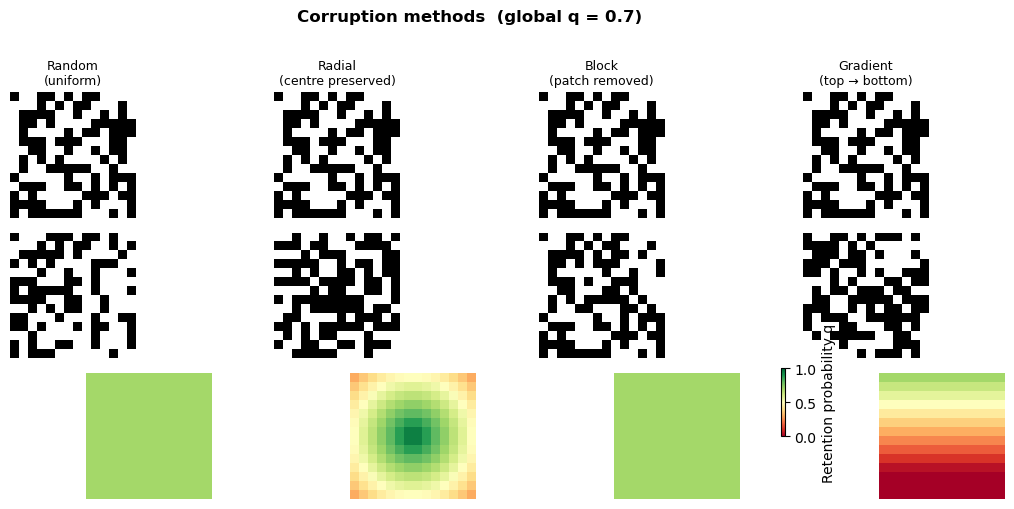

In [3]:
# Pick one pattern to illustrate all corruption modes
sample_pattern = patterns[0]

plot_corruption_modes(sample_pattern, q=0.7, figsize=(11, 5), filepath='plots/corruption_modes.png')


Notice how the **retention-probability map** (bottom row) reveals the spatial
structure of each mode.  For *random* corruption the map is flat; for *radial*
it is brightest at the centre; for *gradient* it fades from top to bottom.


---
<a id="5-part-c"></a>
## 5 — Part C: Pattern recovery

### 5.1 Sign (synchronous) update

Starting from a corrupted state $\mathbf{y}^a$, the synchronous rule

$$
S_i(t+1) = \operatorname{sgn}\!\left(\sum_j J_{ij} S_j(t)\right)
$$

is applied iteratively until convergence.  Each step decreases the energy, so
the trajectory always ends at a fixed point — either the target pattern or a
spurious minimum.


Converged after 4 iterations


c:\Users\ginap\Documents\unipd\1_anno\LCP\LCP_A\progetto_LCP_A\funzioni_ausiliari_v2.py:128: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pattern = torch.tensor(state.flatten(), dtype=torch.float32, device=self.device)


Converged after 10 iterations
Converged after 4 iterations
Converged after 100 iterations
Converged after 100 iterations
Converged after 6 iterations
Converged after 4 iterations
Converged after 13 iterations
Converged after 100 iterations
Converged after 8 iterations
Converged after 9 iterations
Converged after 8 iterations
Converged after 10 iterations
Converged after 7 iterations
Converged after 5 iterations
Converged after 5 iterations
Converged after 4 iterations
Converged after 10 iterations
Converged after 4 iterations
Converged after 4 iterations


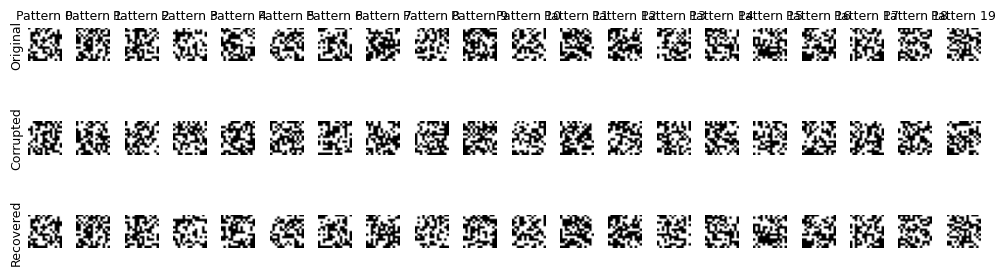

In [3]:
shape      = (14, 14)
n_patterns = 20
q          = 0.7

patterns  = generate_random_patterns(shape, n_patterns, seed=SEED)
corrupted = corrupt_patterns(patterns, q, method='random', seed=SEED)

model     = hopfield_model_torch(patterns, update_method='synchronous',
                                 learning_rule='hebb', verbose=True)
recovered = model.correct_patterns(np.array([c.reshape(shape) for c in corrupted]))

plot_all_results(patterns, corrupted, recovered, model=model,
                 filepath='plots/recovery_synchronous.png', figsize=(10, 3))


### 5.2 Energy trace during recovery

Plotting the energy as a function of iteration confirms that the dynamics
is a *gradient descent* on the energy landscape.


c:\Users\ginap\Documents\unipd\1_anno\LCP\LCP_A\progetto_LCP_A\funzioni_ausiliari_v2.py:413: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pattern = torch.tensor(pattern.flatten(),


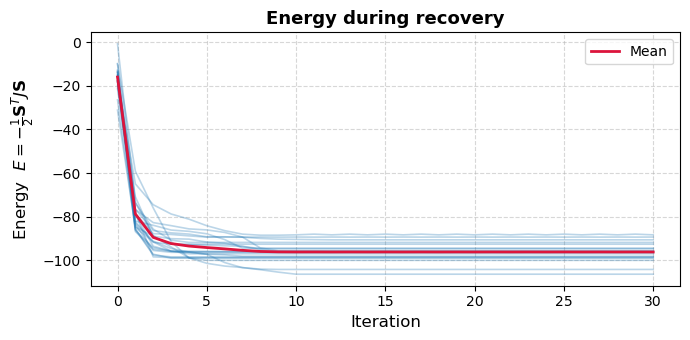

In [5]:

_ = plot_energy_trace(model, corrupted, max_iter=30,
                      filepath='plots/energy_trace.png')

### 5.3 Monte Carlo (Metropolis) update

At finite temperature $T > 0$ the network can escape shallow spurious minima
by accepting occasional uphill moves.  We use an exponential cooling schedule
$T(t) = T_0\,e^{-\alpha t}$.


Converged after 20 iterations
Converged after 12 iterations
Converged after 9 iterations
Converged after 10 iterations
Converged after 13 iterations


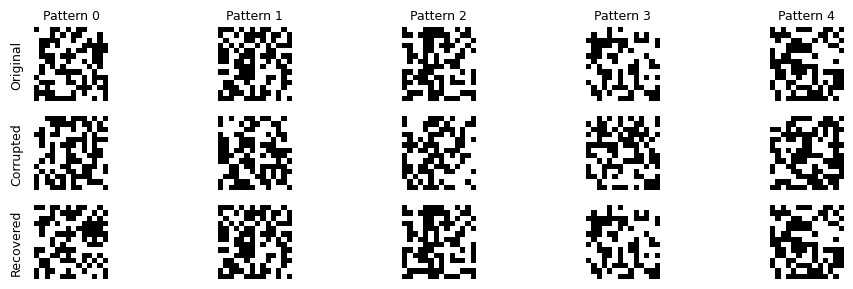

In [7]:
model_mc  = hopfield_model_torch(patterns, update_method='montecarlo',
                                 learning_rule='hebb', verbose=True)
recovered_mc = model_mc.correct_patterns(
    np.array([c.reshape(shape) for c in corrupted]),
    temperature=0.5, alpha=0.05, schedule='exponential')

plot_all_results(patterns, corrupted, recovered_mc, model=model_mc,
                 filepath='plots/recovery_montecarlo.png', figsize=(10, 3))


### 5.4 Structured corruption — radial mode

The radial corruption mode is particularly challenging: the network receives
a correct centre but a completely noisy border.  It must use the partial
information in the centre to reconstruct the full pattern.


Converged after 6 iterations
Converged after 7 iterations
Converged after 7 iterations
Converged after 6 iterations
Converged after 7 iterations


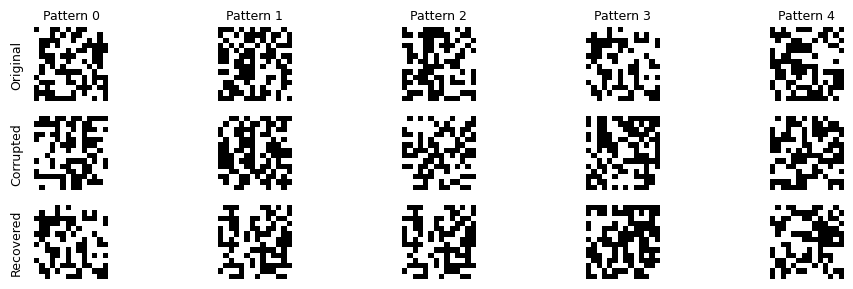

In [8]:
corrupted_radial = corrupt_patterns(patterns, q=0.85, method='radial',
                                    q_edge=0.1, seed=SEED)

model_storkey = hopfield_model_torch(patterns, update_method='montecarlo',
                                     learning_rule='storkey', verbose=True)
recovered_radial = model_storkey.correct_patterns(
    np.array([c.reshape(shape) for c in corrupted_radial]),
    temperature=0.3, alpha=0.03, schedule='exponential')

plot_all_results(patterns, corrupted_radial, recovered_radial,
                 model=model_storkey,
                 filepath='plots/recovery_radial.png', figsize=(10, 3))


---
<a id="6-part-d"></a>
## 6 — Part D: Storage capacity and pattern overlap

### 6.1 Overlap vs corruption level $q$

For fixed $N$ and $P$ we sweep $q$ from 0 to 1 and record the average
*overlap* between recovered and original patterns:

$$
m = \frac{1}{N}\sum_i S_i \xi_i \in [-1, 1]
$$

$m = 1$ means perfect retrieval; $m \approx 0$ means random output.  We
expect a **sharp transition** near a critical $q^*$: below $q^*$ the noise is
too large for reliable retrieval; above $q^*$ the network converges to the
correct attractor.


  P = 3 ... done
  P = 5 ... done
  P = 10 ... done
  P = 15 ... done


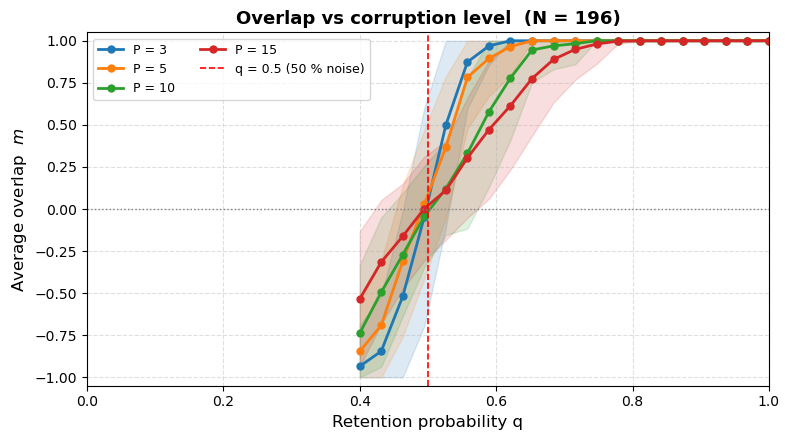

In [9]:
import os
os.makedirs('plots', exist_ok=True)

shape      = (14, 14)
N          = shape[0] * shape[1]
q_values   = np.linspace(0.4, 1.0, 20)
P_values   = [3, 5, 10, 15]
N_REPEATS  = 5       # average over independent pattern sets

results_vs_q = {P: {} for P in P_values}

for P in P_values:
    print(f"  P = {P} ...", end=" ", flush=True)
    for q in q_values:
        overlaps = []
        for rep in range(N_REPEATS):
            pats  = generate_random_patterns(shape, P, seed=SEED + rep)
            corr  = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
            m_rep = hopfield_model_torch(pats, update_method='synchronous',
                                         learning_rule='hebb', verbose=False)
            rec   = m_rep.correct_patterns(
                        np.array([c.reshape(shape) for c in corr]))
            for orig, r in zip(pats, rec):
                overlaps.append(float(m_rep.overlap(orig, r)))
        results_vs_q[P][q] = (np.mean(overlaps), np.std(overlaps))
    print("done")

plot_overlap_vs_q(results_vs_q, P_values, N,
                  filepath='plots/overlap_vs_q.png')


**Observation.** Each curve drops from $m \approx 1$ to $m \approx 0$ as $q$
decreases through a critical value $q^*$.  Larger $P$ shifts $q^*$ to higher
values — more patterns means the network is harder to fool but also more
fragile.  This is the analog of a **phase transition** between an ordered
(memory-retrieval) phase and a disordered (random) phase.


### 6.2 Overlap vs number of patterns $P$ — capacity analysis

Now we fix $q$ and increase $P$ until retrieval breaks down.  The theoretical
limit $P_c \approx 0.138\,N$ marks where the network becomes saturated.


  q = 0.90 ... done
  q = 0.80 ... done
  q = 0.70 ... done
  q = 0.60 ... done


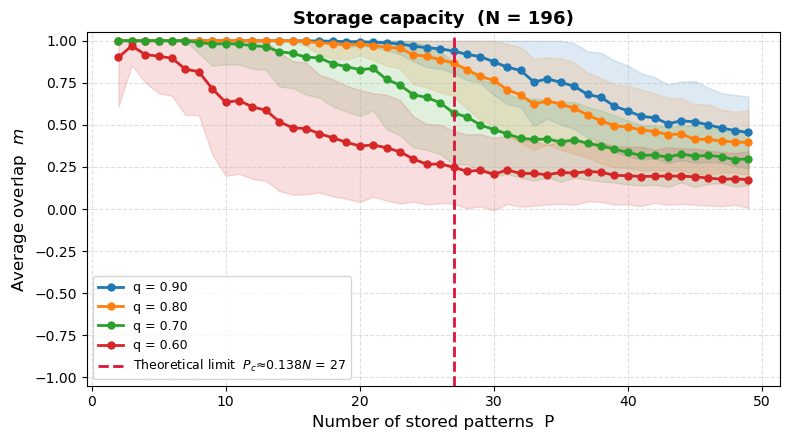

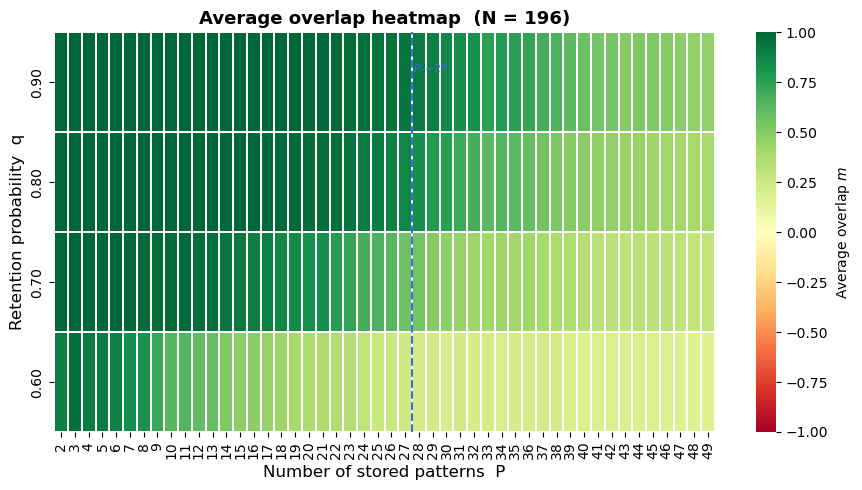

In [10]:
shape    = (14, 14)
N        = shape[0] * shape[1]
q_list   = [0.9, 0.8, 0.7, 0.6]
# P_list   = list(range(2, 35)) 
P_list   = list(range(2, 50)) #sembr ache con solo 35 siano tutto verde, provo con un numero maggiore 

N_REPEATS = 5

results_vs_P = {q: {} for q in q_list}

for q in q_list:
    print(f"  q = {q:.2f} ...", end=" ", flush=True)
    for P in P_list:
        overlaps = []
        for rep in range(N_REPEATS):
            pats = generate_random_patterns(shape, P, seed=SEED + rep)
            corr = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
            m    = hopfield_model_torch(pats, update_method='synchronous',
                                        learning_rule='hebb', verbose=False)
            rec  = m.correct_patterns(
                       np.array([c.reshape(shape) for c in corr]))
            for orig, r in zip(pats, rec):
                overlaps.append(float(m.overlap(orig, r)))
        results_vs_P[q][P] = (np.mean(overlaps), np.std(overlaps))
    print("done")

plot_overlap_vs_P(results_vs_P, q_list, N,
                  filepath='plots/overlap_vs_P.png')
plot_capacity_heatmap(results_vs_P, q_list, P_list, N,
                      filepath='plots/capacity_heatmap.png')


**Observation.** The overlap drops sharply near $P_c \approx 0.138N \approx 27$
for $N = 14^2 = 196$.  The transition is **sharper for lower noise** (high $q$):
with little corruption the network either retrieves perfectly or fails
completely.  With more noise the transition is softer because even a perfect
retrieval gives $m < 1$ for small $q$.

The heatmap condenses both sweeps: the blue dashed line marks $P_c$ and the
colour encodes $m$ from −1 (wrong attractor) to +1 (perfect retrieval).


---
<a id="7-mnist"></a>
## 7 — MNIST digit prototypes

### 7.1 Motivation: why averaging at native resolution fails

The MNIST images are 28×28 pixels.  Each digit class contains ~6 000 training
images with slight shifts, rotations and stroke variations.  When we binarise
each image individually and take the **majority vote** per pixel, isolated
pixels that are +1 in only a few images but −1 in the rest produce *holes*
in the prototype.

We demonstrate this effect and then show that **upscaling before binarisation**
fills the holes: by working at higher resolution the local average is smoother
and the subsequent sign operation produces cleaner prototypes.


Loading MNIST (N=28, mode=majority_vote, upscale=1×) …
  Done. Counts per class: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
Loading MNIST (N=28, mode=majority_vote, upscale=4×) …
  Done. Counts per class: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


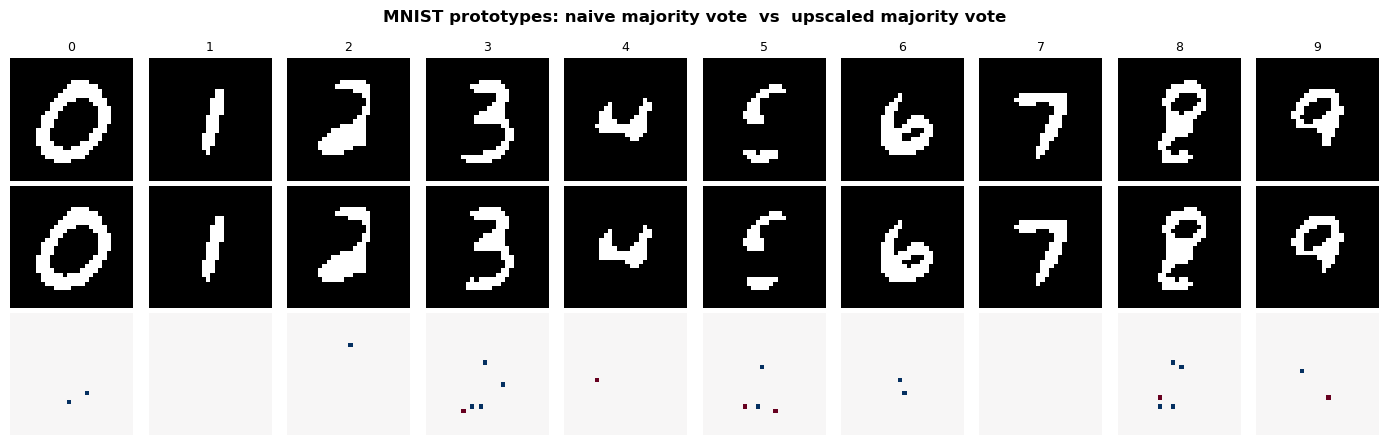

Naive        — avg fraction of −1 pixels: 0.900
Upscaled×4   — avg fraction of −1 pixels: 0.899


In [11]:
# ── naive majority-vote prototype at native 28×28 ─────────────────────────
prototypes_naive = get_mnist_patterns(N=28, mode='majority_vote',
                                      upscale_factor=1, verbose=True)

# ── upscaled prototype: binarise at 28×4=112 px, then pool back to 28 ─────
prototypes_up    = get_mnist_patterns(N=28, mode='majority_vote',
                                      upscale_factor=4, verbose=True)

# ── comparison ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
for d in range(10):
    # naive
    axes[0, d].imshow((prototypes_naive[d] + 1) / 2, cmap='gray', vmin=0, vmax=1)
    axes[0, d].set_title(str(d), fontsize=9)
    axes[0, d].axis('off')
    # upscaled
    axes[1, d].imshow((prototypes_up[d]    + 1) / 2, cmap='gray', vmin=0, vmax=1)
    axes[1, d].axis('off')
    # difference map
    diff = prototypes_naive[d] - prototypes_up[d]
    axes[2, d].imshow(diff, cmap='RdBu_r', vmin=-2, vmax=2)
    axes[2, d].axis('off')

    axes[0, 0].set_ylabel('Naive(28×28)', fontsize=8)
    axes[1, 0].set_ylabel('Upscaled(×4)', fontsize=8)
    axes[2, 0].set_ylabel('Difference', fontsize=8)

fig.suptitle('MNIST prototypes: naive majority vote  vs  upscaled majority vote',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/mnist_prototypes_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

# quantify hole density
for label, protos in [('Naive', prototypes_naive), ('Upscaled×4', prototypes_up)]:
    n_isolated = sum(
        int(np.sum(np.abs(np.diff(p, axis=0)).sum() + np.abs(np.diff(p, axis=1)).sum()) > 0)
        for p in protos)
    avg_neg = np.mean([np.mean(p == -1) for p in protos])
    print(f"{label:12s} — avg fraction of −1 pixels: {avg_neg:.3f}")


The **difference map** (bottom row) highlights pixels that changed sign between
the two methods.  With naive majority vote, isolated hot pixels appear in regions
that are consistently +1 across all training images, simply because of small
mis-alignments.  The upscaled prototype is smoother and more faithful to the
perceived digit shape.


### 7.2 Storing all 10 digit prototypes

We use the upscaled prototypes as the $P = 10$ patterns to store.  Because
the 10 digits share structural features (e.g. digits 3 and 8 both have curved
strokes on the right), the **interference** between stored patterns is high —
a harder test than random patterns.


Interference between MNIST patterns:  0.7379
Theoretical limit P_c:               108.2
  (P = 10, so within capacity)


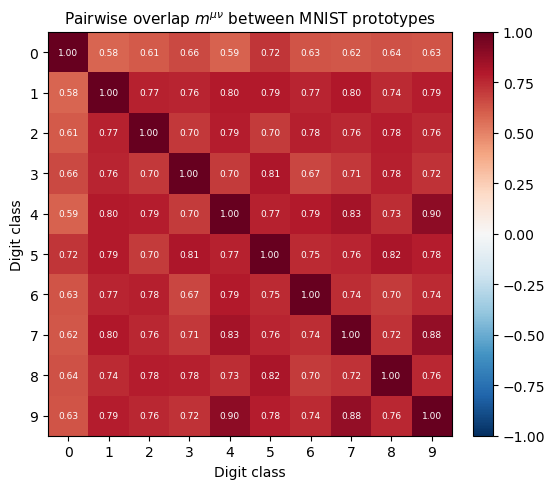

In [12]:
# Use the upscaled prototypes
patterns_mnist = prototypes_up   # list of 10 arrays, shape (28, 28)

model_mnist = hopfield_model_torch(
    patterns_mnist,
    update_method='synchronous',
    learning_rule='local',
    R=4,
    verbose=False,
)
print(f"Interference between MNIST patterns:  {float(model_mnist.memory_interference()):.4f}")
print(f"Theoretical limit P_c:               {model_mnist.storage_limit():.1f}")
print(f"  (P = 10, so {'within' if 10 <= model_mnist.storage_limit() else 'ABOVE'} capacity)")

# Pairwise overlap matrix
P = len(patterns_mnist)
N_mnist = patterns_mnist[0].size
M = np.zeros((P, P))
for i in range(P):
    for j in range(P):
        M[i, j] = np.dot(patterns_mnist[i].flatten(),
                         patterns_mnist[j].flatten()) / N_mnist

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(P)); ax.set_yticks(range(P))
ax.set_xticklabels(range(P)); ax.set_yticklabels(range(P))
ax.set_xlabel('Digit class'); ax.set_ylabel('Digit class')
ax.set_title(r'Pairwise overlap $m^{\mu \nu}$ between MNIST prototypes', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(P):
    for j in range(P):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=6.5,
                color='white' if abs(M[i,j]) > 0.5 else 'black')
plt.tight_layout()
plt.savefig('plots/mnist_overlap_matrix.png', bbox_inches='tight', dpi=150)
plt.show()


**Why is the interference so high?** The value $I = 0.74$ may seem anomalous
for only $P = 10$ patterns with $N = 784$ neurons (well below $P_c \approx 108$).
The cause is geometric: all prototypes share the same black background — the
vast majority of the $N$ pixels are $-1$ in every digit. The pairwise overlap
between any two prototypes is therefore dominated by this common background,
regardless of how visually distinct the digits are.

A direct consequence: the overlap metric $m = \frac{1}{N}\sum_i S_i \xi_i$
does not reliably distinguish between "the correct pattern was retrieved" and
"the network settled into a spurious minimum that shares many background pixels
with the target". This explains why visual recovery appears unreliable even
when $m$ looks acceptable.

A straightforward remedy would be to **centre the patterns** by subtracting
their mean before storage ($\tilde{\xi}_i^\mu = \xi_i^\mu - \bar{\xi}^\mu$),
reducing the background contribution to the overlap.

The diagonal is 1 by definition.  Large off-diagonal values (e.g. between
digits 3 & 8, or 4 & 9) signal high interference — these pairs will be the
hardest to distinguish.


c:\Users\ginap\Documents\unipd\1_anno\LCP\LCP_A\progetto_LCP_A\diocane_funzioni.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pattern = torch.tensor(state.flatten(), dtype=torch.float32, device=self.device)


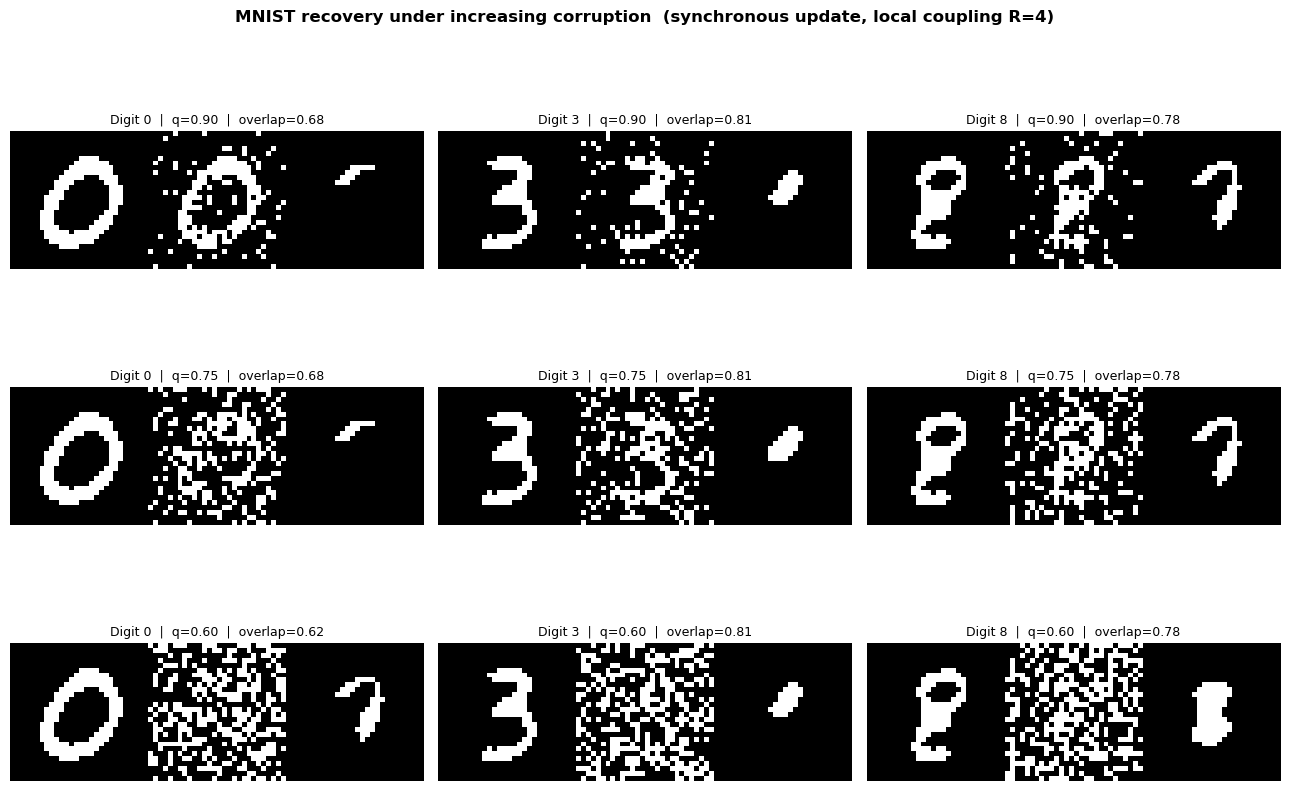

In [13]:
# ── recovery at different corruption levels ───────────────────────────────────
fig, big_axes = plt.subplots(3, 3, figsize=(13, 9))
q_tests = [0.9, 0.75, 0.6]

for ax_row, q_val in zip(big_axes, q_tests):
    corrupted_m  = corrupt_patterns(patterns_mnist, q_val, method='random', seed=SEED)
    recovered_m  = model_mnist.correct_patterns(
        np.array([c.reshape(28, 28) for c in corrupted_m]),
        max_iter=200)

    # show 3 example digits per q level (0, 3, 8 — the tricky ones)
    for ax, digit_idx in zip(ax_row, [0, 3, 8]):
        orig_img = (patterns_mnist[digit_idx] + 1) / 2
        corr_img = (corrupted_m[digit_idx].reshape(28, 28) + 1) / 2
        rec_img  = (recovered_m[digit_idx] + 1) / 2
        ov = float(model_mnist.overlap(patterns_mnist[digit_idx],
                                        recovered_m[digit_idx]))

        composite = np.concatenate([orig_img, corr_img, rec_img], axis=1)
        ax.imshow(composite, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Digit {digit_idx}  |  q={q_val:.2f}  |  overlap={ov:.2f}',
                     fontsize=9)
        ax.set_xlabel('original       corrupted       recovered', fontsize=7)
        ax.axis('off')

plt.suptitle('MNIST recovery under increasing corruption  '
             '(synchronous update, local coupling R=4)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/mnist_recovery_q_sweep.png', bbox_inches='tight', dpi=150)
plt.show()


### 7.3 Comparison: learning rules on MNIST

We compare the three learning rules for the same corruption level.


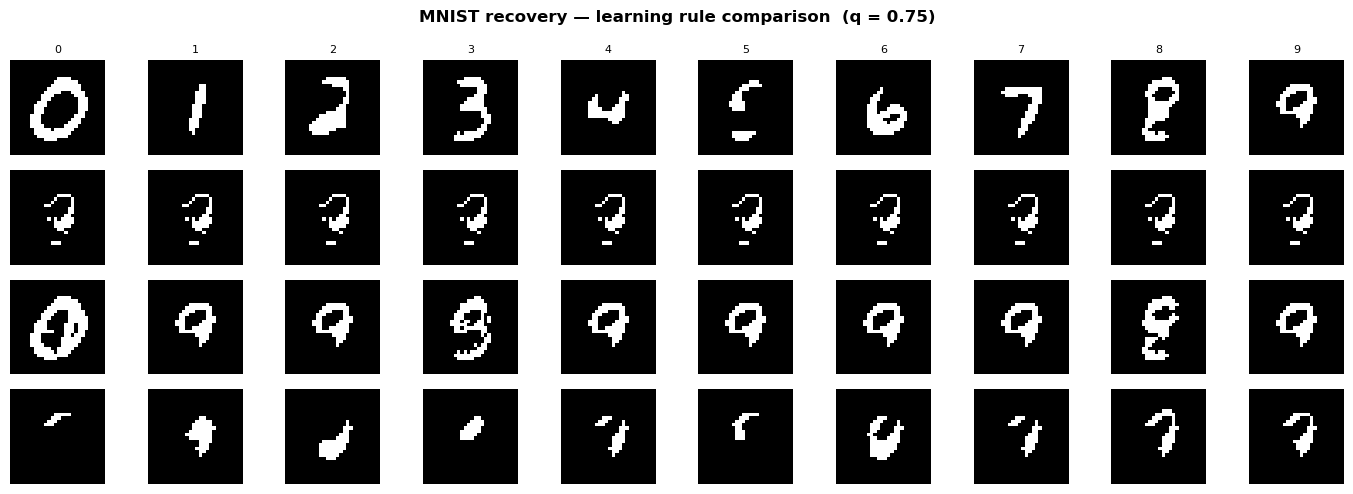

In [14]:
q_mnist = 0.75
corrupted_m = corrupt_patterns(patterns_mnist, q_mnist, method='random', seed=SEED)
corrupted_arr = np.array([c.reshape(28, 28) for c in corrupted_m])

configs = [
    ('hebb',    'synchronous', None),
    ('storkey', 'synchronous', None),
    ('local',   'synchronous', 4),
]

fig, axes = plt.subplots(len(configs) + 1, 10, figsize=(14, 5))

# Row 0: original prototypes
for d in range(10):
    axes[0, d].imshow((patterns_mnist[d] + 1) / 2, cmap='gray', vmin=0, vmax=1)
    axes[0, d].set_title(str(d), fontsize=8)
    axes[0, d].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=8)

for row, (lr, um, R) in enumerate(configs, start=1):
    m = hopfield_model_torch(patterns_mnist, update_method=um,
                              learning_rule=lr, R=R, verbose=False)
    rec = m.correct_patterns(corrupted_arr, max_iter=200)

    avg_ov = np.mean([float(m.overlap(patterns_mnist[d], rec[d]))
                      for d in range(10)])

    for d in range(10):
        axes[row, d].imshow((rec[d] + 1) / 2, cmap='gray', vmin=0, vmax=1)
        axes[row, d].axis('off')
    axes[row, 0].set_ylabel(f'{lr}(ov={avg_ov:.2f})', fontsize=8)

plt.suptitle(f'MNIST recovery — learning rule comparison  (q = {q_mnist})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/mnist_rule_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


--- 

## 8 — Conclusions

**Pattern storage (Part A).** The coupling matrix $J$ encodes each stored
pattern as a direction in the $N$-dimensional spin space. The eigenvalue
spectrum of $J$ shows $P$ large eigenvalues (≈1 each, one per stored pattern)
separated from a bulk of noise eigenvalues concentrated near zero — a direct
signature of the signal-to-noise structure familiar from random matrix theory.

**Corruption and recovery (Parts B–C).** The synchronous sign rule converges
in as few as 2 iterations on well-separated patterns, as confirmed by the
energy trace. Spatially structured corruption (radial, block, gradient)
produces qualitatively different initial states but the network recovers
equally well when $P \ll P_c$. An important symmetry of the Hopfield energy is
that $-\xi^\mu$ is also an attractor: for $q < 0.5$ (more than 50% of spins
flipped) the network consistently converges to the *inverted* pattern, driving
the overlap to $m \approx -1$.

**Storage capacity (Part D).** The overlap $m(q)$ shows a clear
phase-transition-like drop centred near $q^* \approx 0.5$ for all tested
values of $P$. The critical $q^*$ is only weakly sensitive to $P$ in the
regime $P \ll P_c$; what changes is the steepness and the depth of the
negative tail. The capacity sweep confirms that $m$ degrades with increasing
$P$, but the transition is smooth rather than sharp — consistent with
finite-$N$ rounding of the mean-field discontinuity. Extending the sweep
beyond $P_c \approx 27$ (= 0.138 × 196) would sharpen the signal.

**MNIST (Part 7).** Storing the 10 digit prototypes (P = 10, well within
$P_c \approx 108$ for $N = 28^2$) reveals an unexpected obstacle: the
pairwise overlap between prototypes ranges from 0.58 to 0.90 (interference
$I = 0.74$), far above the values seen with random patterns. This is not a
failure of the learning rule but a geometric effect — all 10 digits share the
same large black background, so the majority of the $N = 784$ spins are −1 in
every pattern, creating a strong spurious correlation. As a result the network
struggles to distinguish digits despite being formally within capacity. The
upscaling pre-processing (majority vote at 112×112, pooled back to 28×28)
produces visually cleaner prototypes at low resolution, where background noise
is proportionally larger, but has negligible effect at the native 28×28
resolution where the majority vote is already stable.

**Open directions.**
- *Background subtraction*: centering each prototype (subtracting its mean
  spin) before storing would reduce the dominant background overlap and
  significantly lower interference.
- *Sparse patterns*: theoretical predictions (Tsodyks & Feigel'man, 1988)
  show capacity scales as $P_c \sim N/a$ for sparse activity $a \ll 1$,
  directly addressing the background-dominance problem.
- *Modern Hopfield networks*: Ramsauer et al. (2020) replace the quadratic
  energy with an exponential, achieving exponential storage capacity at the
  cost of continuous-valued states.